In [47]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Load Data

In [48]:
data = load_iris()
X = data.data
y = data.target

In [49]:
# 標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [50]:
# df.info()

In [51]:
# df.describe()

In [52]:
counts = np.bincount(y)
for i, count in enumerate(counts):
    print(f"Class {i}: {count} instances")

Class 0: 50 instances
Class 1: 50 instances
Class 2: 50 instances


# 二、降維 PCA、LDA

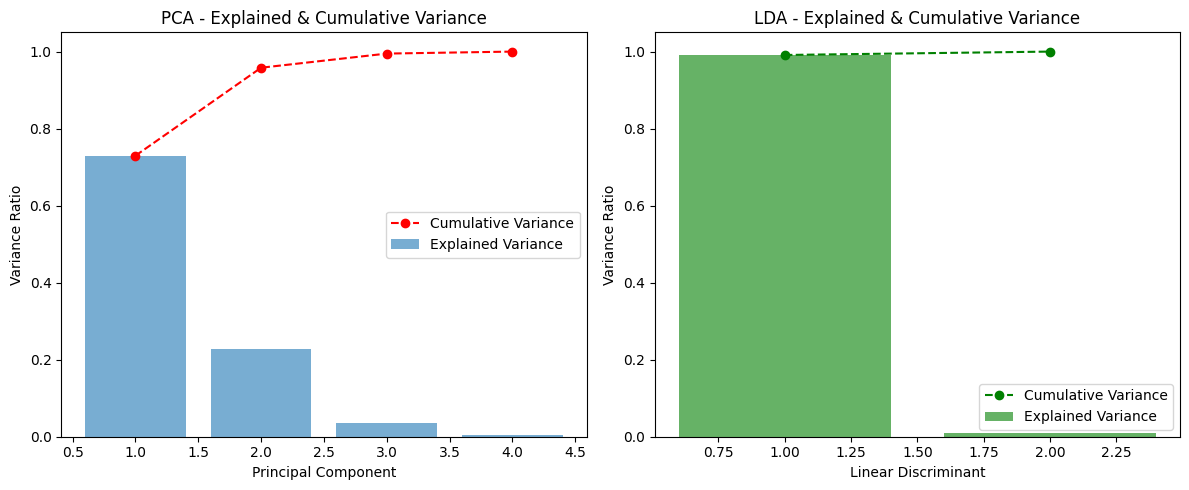

In [53]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# ===== PCA =====
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var_ratio_pca = pca.explained_variance_ratio_
cumulative_var_ratio_pca = np.cumsum(explained_var_ratio_pca)

# ===== LDA =====
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

explained_var_ratio_lda = lda.explained_variance_ratio_
cumulative_var_ratio_lda = np.cumsum(explained_var_ratio_lda)

# ===== 繪圖區塊 =====
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ===== PCA 圖 =====
axes[0].bar(range(1, len(explained_var_ratio_pca)+1), explained_var_ratio_pca, alpha=0.6, label='Explained Variance')
axes[0].plot(range(1, len(cumulative_var_ratio_pca)+1), cumulative_var_ratio_pca, 'ro--', label='Cumulative Variance')
axes[0].set_title('PCA - Explained & Cumulative Variance')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Ratio')
axes[0].legend()

# ===== LDA 圖 =====
axes[1].bar(range(1, len(explained_var_ratio_lda)+1), explained_var_ratio_lda, color='green', alpha=0.6, label='Explained Variance')
axes[1].plot(range(1, len(cumulative_var_ratio_lda)+1), cumulative_var_ratio_lda, 'go--', label='Cumulative Variance')
axes[1].set_title('LDA - Explained & Cumulative Variance')
axes[1].set_xlabel('Linear Discriminant')
axes[1].set_ylabel('Variance Ratio')
axes[1].legend()

plt.tight_layout()
plt.show()

**PCA（主成分分析）**
1.   左（PCA - Explained Variance）
*   顯示前幾個 Principal Components 的解釋變異數比率。
*   第 1 主成分解釋了超過 70% 的變異，前兩個就已經超過 95%，降維效果佳。

2.   右（PCA - Cumulative Explained Variance）
*   紅色虛線折線圖顯示累積解釋變異數，前兩個主成分已能涵蓋接近全部資訊。

**LDA（線性判別分析）**
1.   右（LDA - Explained Variance）
*   綠色柱狀圖顯示前兩個 LDA 分量（LD1, LD2）的解釋變異數。
*   LD1 幾乎貢獻了所有的分類資訊，LD2 很少，表示一個判別軸就已足夠辨別三類。

2.   右（LDA - Cumulative Explained Variance）
*   綠色虛線顯示累積解釋變異數，比率迅速趨近 1。
*   這證明 Iris 資料只需一到兩個 LDA 分量就能有效區分類別。


In [54]:
# from sklearn.decomposition import PCA
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# # ===== PCA =====
# pca = PCA()
# X_pca = pca.fit_transform(X_scaled)

# explained_var_ratio_pca = pca.explained_variance_ratio_
# cumulative_var_ratio_pca = np.cumsum(explained_var_ratio_pca)

# # ===== LDA =====
# lda = LDA(n_components=2)
# X_lda = lda.fit_transform(X_scaled, y)

# explained_var_ratio_lda = lda.explained_variance_ratio_
# cumulative_var_ratio_lda = np.cumsum(explained_var_ratio_lda)

# # ===== 繪圖區塊 =====
# fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# # ===== PCA 解釋變異數 =====
# axes[0, 0].bar(range(1, len(explained_var_ratio_pca)+1), explained_var_ratio_pca)
# axes[0, 0].set_title('PCA - Explained Variance')
# axes[0, 0].set_xlabel('Principal Component')
# axes[0, 0].set_ylabel('Explained Variance Ratio')

# # ===== PCA 累積變異數 =====
# axes[0, 1].plot(range(1, len(cumulative_var_ratio_pca)+1), cumulative_var_ratio_pca, 'ro--')
# axes[0, 1].set_title('PCA - Cumulative Explained Variance')
# axes[0, 1].set_xlabel('Number of Principal Components')
# axes[0, 1].set_ylabel('Cumulative Explained Variance')

# # ===== LDA 解釋變異數 =====
# axes[1, 0].bar(range(1, len(explained_var_ratio_lda)+1), explained_var_ratio_lda, color='green')
# axes[1, 0].set_title('LDA - Explained Variance')
# axes[1, 0].set_xlabel('Linear Discriminant')
# axes[1, 0].set_ylabel('Explained Variance Ratio')

# # ===== LDA 累積變異數 =====
# axes[1, 1].plot(range(1, len(cumulative_var_ratio_lda)+1), cumulative_var_ratio_lda, 'go--')
# axes[1, 1].set_title('LDA - Cumulative Explained Variance')
# axes[1, 1].set_xlabel('Number of LD Components')
# axes[1, 1].set_ylabel('Cumulative Explained Variance')

# plt.tight_layout()
# plt.show()

**PCA（主成分分析）**
1.   左上（PCA - Explained Variance）
*   顯示前幾個 Principal Components 的解釋變異數比率。
*   第 1 主成分解釋了超過 70% 的變異，前兩個就已經超過 95%，降維效果佳。

2.   右上（PCA - Cumulative Explained Variance）
*   紅色虛線折線圖顯示累積解釋變異數，前兩個主成分已能涵蓋接近全部資訊。

**LDA（線性判別分析）**
1.   左下（LDA - Explained Variance）
*   綠色柱狀圖顯示前兩個 LDA 分量（LD1, LD2）的解釋變異數。
*   LD1 幾乎貢獻了所有的分類資訊，LD2 很少，表示一個判別軸就已足夠辨別三類。

2.   右下（LDA - Cumulative Explained Variance）
*   綠色虛線顯示累積解釋變異數，比率迅速趨近 1。
*   這證明 Iris 資料只需一到兩個 LDA 分量就能有效區分類別。


# 三、決定要取幾個主成分

In [55]:
cumulative_var_ratio_pca

array([0.72962445, 0.95813207, 0.99482129, 1.        ])

前 2 個主成分就能保留 95.8% 的變異數，所以我們選 PCA 降維取前 2 個主成分

# 四、降維之後用 LogisticRegression、SVM 建模

In [56]:
# PCA 降維取前 2 維
X_pca_2 = X_pca[:, :2]

# Train-test split
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca_2, y, test_size=0.2, random_state=42)
X_train_lda, X_test_lda, _, _ = train_test_split(X_lda, y, test_size=0.2, random_state=42)

# 建立模型
models = {
    "Logistic Regression (PCA)": LogisticRegression(),
    "SVM (PCA)": SVC(),
    "Logistic Regression (LDA)": LogisticRegression(),
    "SVM (LDA)": SVC()
}

# 訓練與評估
for name, model in models.items():
    if "PCA" in name:
        model.fit(X_train_pca, y_train)
        y_pred = model.predict(X_test_pca)
    else:
        model.fit(X_train_lda, y_train)
        y_pred = model.predict(X_test_lda)

    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression (PCA) Accuracy: 0.9000
SVM (PCA) Accuracy: 0.9000
Logistic Regression (LDA) Accuracy: 1.0000
SVM (LDA) Accuracy: 1.0000


# 五、output (1)Accuracy (2)決策圖

LogisticRegression_PCA Accuracy: 0.9000
SVM_PCA Accuracy: 0.9000
LogisticRegression_LDA Accuracy: 1.0000
SVM_LDA Accuracy: 1.0000


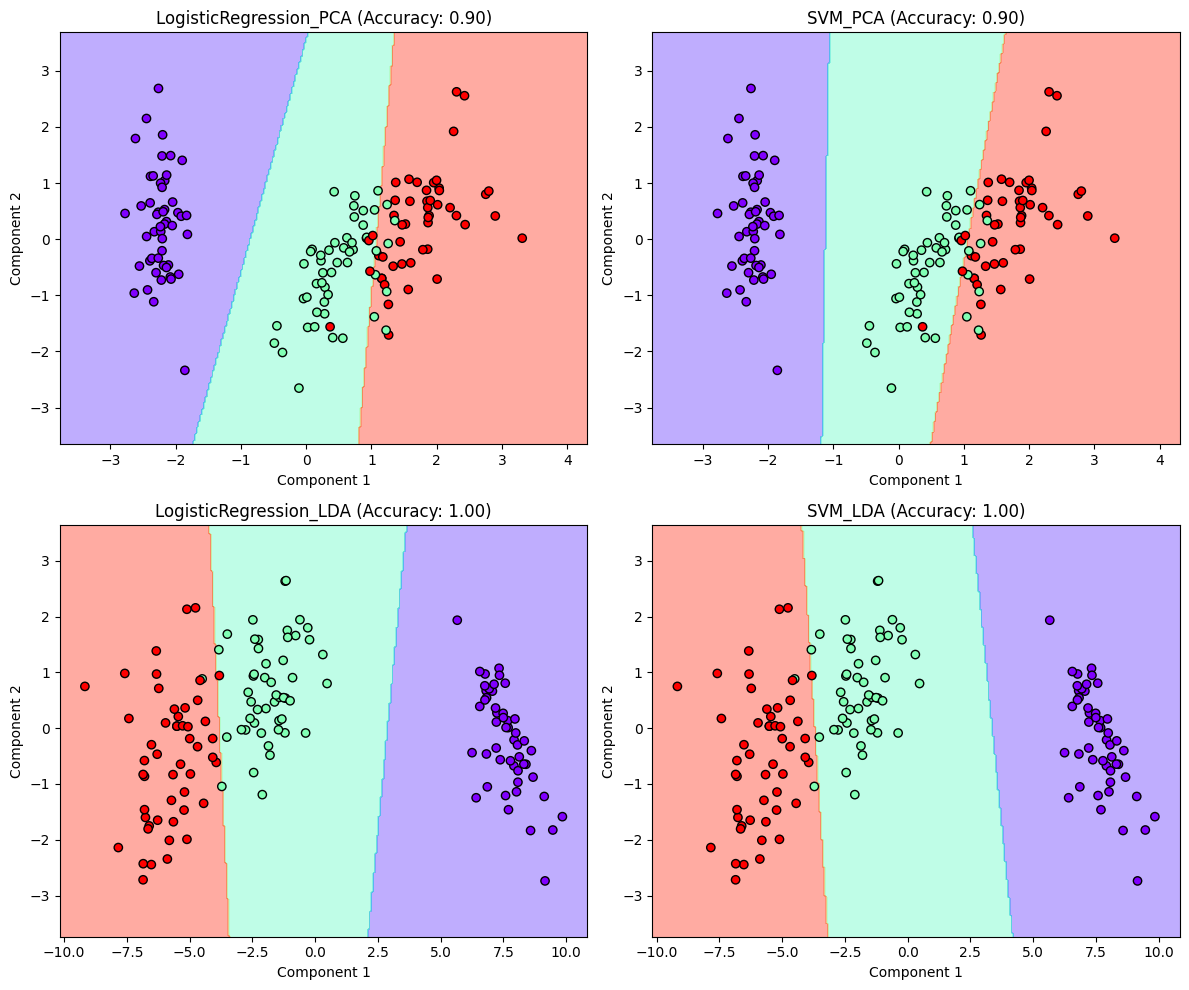

In [57]:
# ===== 1. 載入資料與標準化 =====
data = load_iris()
X = data.data
y = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===== 2. 降維處理 =====
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

# ===== 3. 分割資料 =====
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)
X_train_lda, X_test_lda, _, _ = train_test_split(X_lda, y, test_size=0.2, random_state=42)

# ===== 4. 建立模型與預測 =====
models = {
    'LogisticRegression_PCA': (LogisticRegression(), X_train_pca, X_test_pca),
    'SVM_PCA': (SVC(kernel='linear'), X_train_pca, X_test_pca),
    'LogisticRegression_LDA': (LogisticRegression(), X_train_lda, X_test_lda),
    'SVM_LDA': (SVC(kernel='linear'), X_train_lda, X_test_lda),
}

# ===== 5. 畫出決策邊界圖函數 =====
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.rainbow)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.rainbow)
    plt.title(title)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')

# ===== 6. 訓練、評估並畫圖 =====
plt.figure(figsize=(12, 10))
for i, (name, (model, X_train, X_test)) in enumerate(models.items(), 1):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")

    plt.subplot(2, 2, i)
    plot_decision_boundary(model, np.vstack((X_train, X_test)), np.hstack((y_train, y_test)),
                           f"{name} (Accuracy: {acc:.2f})")

plt.tight_layout()
plt.show()

# 六、Accuracy 比較圖(LR/SVM)

In [58]:
# 1.原本
# 2.選重要性特徵 (上次作業)
# 3.降維 (本次作業)

# 請自行整理